In [36]:
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
import sympy as sy
from numpy import linspace, ones
import numpy as np
from matplotlib import pyplot as plt
from time import time


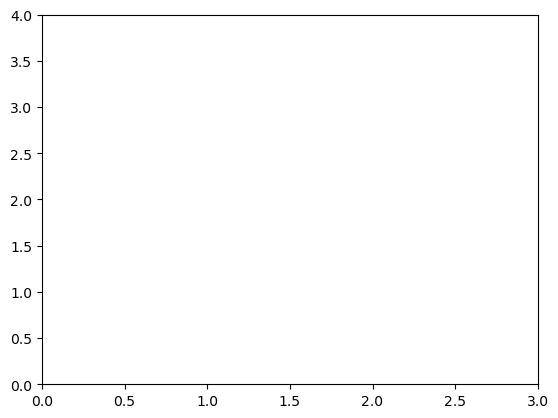

In [37]:
# grille pour Dirichlet 2D
# 
L=3
H=4
Nx=100
Ny=100
dx=L/(Nx)
dy=H/(Ny)
x=linspace(0,L-dx,Nx)
y=linspace(0,H-dy,Ny)

#liste des numéros des noeuds presentants 4 voisins faisant partie des noeuds où la solution est inconnue
# soient les noeuds en Xint_1,Yint_1
Linterieur = []
for i in range(1, Nx-1):
    for j in range(1, Ny-1):
        Linterieur.append(i + j*Nx)
        

plt.xlim(0, L)
plt.ylim(0, H)
#print(Linterieur)

#liste des noeuds du bas sauf coins
Lbas=[i for i in range(1,Nx-1)]
#liste des noeuds du haut sauf coins
Lhaut=[i for i in range(Nx*(Ny-1)+1,Nx*Ny-1)]
#liste des noeuds de gauche sauf coins
Lgauche=[i*Nx for i in range(1,Ny-1)]
#liste des noeuds de droite sauf coins
Ldroite=[i*Nx-1 for i in range(2,Ny)]


A=lil_matrix((Nx*Ny,Nx*Ny))
#construction de la diagonale de A
for k in range(Nx*Ny):
    A[k,k]=2/dx**2+2/dy**2
#construction de la matrice A pour les noeuds presentants 4 voisins inconnus
for k in Linterieur:
    A[k,k+1]=-1/dx**2
    A[k,k-1]=-1/dx**2
    A[k,k+Nx]=-1/dy**2
    A[k,k-Nx]=-1/dy**2
# contribution pour les noeuds du bas
for k in Lbas:
    A[k,k+1]=-1/dx**2
    A[k,k-1]=-1/dx**2
    A[k,k+Nx]=-2/dy**2
# contribution pour les noeuds du haut
for k in Lhaut:
    A[k,k+1]=-1/dx**2
    A[k,k-1]=-1/dx**2
    A[k,k-Nx]=-1/dy**2
# contribution pour les noeuds de gauche
for k in Lgauche:
    A[k,k+1]=-2/dx**2
    A[k,k+Nx]=-1/dy**2
    A[k,k-Nx]=-1/dy**2
# contribution pour les noeuds de droite
for k in Ldroite:
    A[k,k-1]=-1/dx**2
    A[k,k+Nx]=-1/dy**2
    A[k,k-Nx]=-1/dy**2
#coin bas gauche
k=0
A[k,k+1]=-2/dx**2
A[k,k+Nx]=-2/dy**2
#coin bas droite
k=Nx-1
A[k,k-1]=-1/dx**2
A[k,k+Nx]=-2/dy**2
#coin haut gauche
k=Nx*(Ny-1)
A[k,k+1]=-2/dx**2
A[k,k-Nx]=-1/dy**2
#coin haut droite
k=Nx*Ny-1
A[k,k-1]=-1/dx**2
A[k,k-Nx]=-1/dy**2

A= A.tocsr()

#construction d'un second membre trivial
f=-ones(Nx*Ny)
#
#resolution du systeme lineaire creux
#
t=time()
u=spsolve(A,f)
t2=time()

#print(A.toarray())

In [38]:
f = lambda x,y : x*x*y*y*sy.sin(H-y)*sy.sin(x-L)
x,y = sy.symbols('x y')
#print(sy.diff(f, x, 2) + sy.diff(f, y, 2))

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

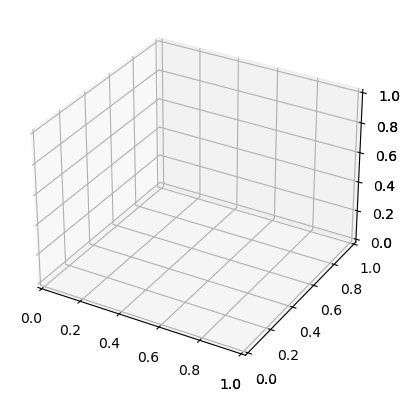

In [40]:
uu=u.reshape((Ny,Nx))

from mpl_toolkits import mplot3d
ax = plt.axes(projection='3d')
xx,yy = np.meshgrid(x, y)
ax = plt.axes(projection='3d')
#ax.contour3D(X, Y, uubord, 50, cmap='binary')
ax.plot_surface(xx, yy, uu, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none');
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u');
ax.view_init(20, -125)